# 01 — DUC dataset audit and TextRank baseline

## Goal

Kiểm tra train/test/reference và đo baseline hiện tại trước khi tối ưu tham số.

## Setup

Khởi tạo đường dẫn, module thuật toán và thư mục artifact.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / 'data' / 'DUC_TEXT').is_dir():
            PROJECT_ROOT = candidate
            break

NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'textrank-parameter-analysis'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from experiment_utils import *

TRAIN_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'train'
TEST_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'test'
REFERENCE_DIR = PROJECT_ROOT / 'data' / 'DUC_SUM'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'output' / 'textrank-parameter-analysis'
CSV_DIR = OUTPUT_DIR / 'csv'
CHART_DIR = OUTPUT_DIR / 'charts'
CSV_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Project: {PROJECT_ROOT}')
print(f'Output : {OUTPUT_DIR}')

Project: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice
Output : /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/textrank-parameter-analysis


## Steps

### 1. Audit dataset

In [2]:
train_paths = sorted(path for path in TRAIN_DIR.iterdir() if path.is_file())
test_paths = sorted(path for path in TEST_DIR.iterdir() if path.is_file())
dataset_rows = []
for split, paths in [('train', train_paths), ('test', test_paths)]:
    for topic_path in paths:
        reference_path = REFERENCE_DIR / topic_path.name
        assert reference_path.is_file(), f'Missing reference: {topic_path.name}'
        input_sentences = read_topic(topic_path)
        reference_sentences = read_topic(reference_path)
        shortest = sorted(len(sentence.content.split()) for sentence in reference_sentences)
        used = 0
        ceiling = 0
        for word_count in shortest:
            if used + word_count > 100:
                continue
            used += word_count
            ceiling += 1
        dataset_rows.append({
            'split': split, 'topic': topic_path.name,
            'input_sentences': len(input_sentences),
            'input_words': sum(len(sentence.content.split()) for sentence in input_sentences),
            'reference_sentences': len({sentence.key for sentence in reference_sentences}),
            'reference_words': sum(len(sentence.content.split()) for sentence in reference_sentences),
            'reference_sentence_ceiling_100_words': ceiling,
        })
write_csv(CSV_DIR / '01-dataset-summary.csv', dataset_rows, list(dataset_rows[0]))
print(f'Train topics: {len(train_paths)} | Test topics: {len(test_paths)}')

Train topics: 50 | Test topics: 9


### 2. Run baseline

In [3]:
BASELINE = TextRankConfig()
baseline_rows = evaluate_config(TRAIN_DIR, REFERENCE_DIR, BASELINE, 'train')
baseline_summary = aggregate_rows(baseline_rows)
for row in baseline_rows:
    row['config_id'] = config_id(BASELINE)
write_csv(CSV_DIR / '01-baseline-topic-metrics.csv', baseline_rows, DETAIL_FIELDS)
print({key: round(value, 4) if isinstance(value, float) else value
       for key, value in baseline_summary.items()})

{'eligible_topics': 34, 'converged_topics': 50, 'macro_precision': 0.0918, 'macro_recall': 0.0383, 'macro_f1': 0.0534, 'macro_hit_at_1': 0.2353, 'macro_hit_at_3': 0.3824, 'macro_hit_at_5': 0.4706, 'mean_density': 0.0337, 'mean_isolated_ratio': 0.0361, 'mean_average_degree': 9.4157, 'mean_connected_components': 11.66, 'mean_redundancy': 0.0655, 'max_redundancy': 1.0, 'mean_word_count': 99.82, 'mean_budget_utilization': 0.9982, 'mean_pagerank_iterations': 55.74, 'mean_runtime_seconds': 0.0569}


### 3. Visualize baseline and reference size

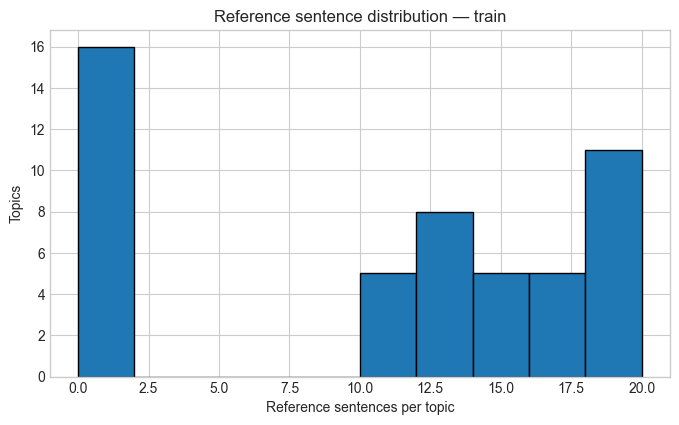

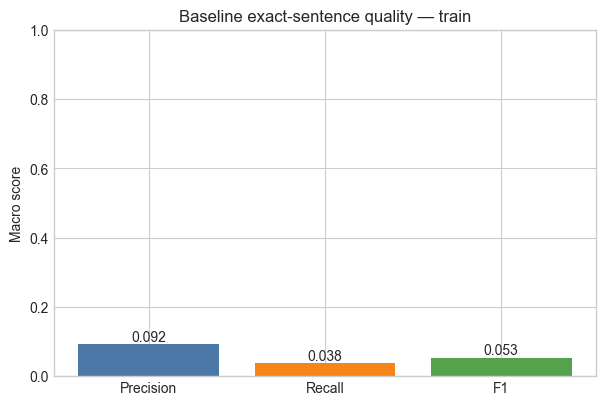

In [4]:
train_reference_counts = [row['reference_sentences'] for row in dataset_rows if row['split'] == 'train']
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(train_reference_counts, bins=10, edgecolor='black')
ax.set(title='Reference sentence distribution — train', xlabel='Reference sentences per topic', ylabel='Topics')
fig.savefig(CHART_DIR / '01-reference-sentence-distribution.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
names = ['Precision', 'Recall', 'F1']
values = [baseline_summary['macro_precision'], baseline_summary['macro_recall'], baseline_summary['macro_f1']]
bars = ax.bar(names, values, color=['#4c78a8', '#f58518', '#54a24b'])
ax.set(title='Baseline exact-sentence quality — train', ylabel='Macro score', ylim=(0, 1))
ax.bar_label(bars, fmt='%.3f')
fig.savefig(CHART_DIR / '01-baseline-metrics.png', dpi=160, bbox_inches='tight')
plt.show()

## Checks

Các assertion dưới đây bảo đảm artifact và dữ liệu của notebook đầy đủ.

In [5]:
assert len(train_paths) == 50
assert len(test_paths) == 9
assert len(baseline_rows) == 50
for path in [CSV_DIR / '01-dataset-summary.csv', CSV_DIR / '01-baseline-topic-metrics.csv',
             CHART_DIR / '01-reference-sentence-distribution.png', CHART_DIR / '01-baseline-metrics.png']:
    assert path.is_file() and path.stat().st_size > 0, path
print('All dataset and baseline checks passed.')

All dataset and baseline checks passed.


## Takeaways

In [6]:
print(f"Baseline macro Precision={baseline_summary['macro_precision']:.4f}, "
      f"F1={baseline_summary['macro_f1']:.4f}.")
print(f"Mean word-budget utilization={baseline_summary['mean_budget_utilization']:.3f}.")
print('Recall is interpreted with care because DUC_SUM is longer than the 100-word prediction budget.')

Baseline macro Precision=0.0918, F1=0.0534.
Mean word-budget utilization=0.998.
Recall is interpreted with care because DUC_SUM is longer than the 100-word prediction budget.
